
# Out-of-Distribution Generalization for Fisher-Regularized Neural Surrogates

This notebook computes the out-of-distribution (OOD) generalization table for the Fisher-regularized Gaussian variance dynamics:

\[
\dot{u}=2(1-u)+\frac{\varepsilon}{u}.
\]

The neural surrogates are trained only on the standard domain:

\[
u_0\in[0.2,2.5],\qquad \varepsilon\in[0.01,0.5],\qquad t\in[0,5].
\]

They are then evaluated without retraining on four OOD regimes: low variance, high variance, high Fisher strength, and longer time. Results are reported as mean \(\pm\) 95% confidence-interval half-width over \(S=10\) random seeds.


In [ ]:

import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

try:
    from scipy.stats import t as student_t
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.11.0+cpu
CUDA available: False


## Configuration

In [ ]:

CONFIG = {
    "n_pairs": 300,
    "n_time": 80,
    "t_max": 5.0,
    "u0_min": 0.2,
    "u0_max": 2.5,
    "eps_min": 0.01,
    "eps_max": 0.5,
    "n_ood_pairs": 120,
    "n_seeds": 10,
    "data_seed": 123,
    "split_seed": 999,
    "base_seed": 2026,
    "epochs": 1500,
    "batch_size": 512,
    "lr": 2e-3,
    "patience": 150,
    "quick_test": False,
}

if CONFIG["quick_test"]:
    CONFIG.update({
        "n_pairs": 80,
        "n_time": 50,
        "n_ood_pairs": 40,
        "n_seeds": 2,
        "epochs": 200,
        "patience": 40,
    })

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cpu'

## Fisher-Regularized Dynamics

In [ ]:

def u_star(eps):
    eps = np.asarray(eps)
    return (1.0 + np.sqrt(1.0 + 2.0 * eps)) / 2.0

def u_ou(t, u0):
    return 1.0 + (u0 - 1.0) * np.exp(-2.0 * t)

def rhs(u, eps):
    return 2.0 * (1.0 - u) + eps / np.maximum(u, 1e-12)

def integrate_rk4(u0, eps, t_grid):
    u = np.zeros_like(t_grid, dtype=np.float64)
    u[0] = float(u0)

    for k in range(1, len(t_grid)):
        dt = t_grid[k] - t_grid[k - 1]
        uk = u[k - 1]
        k1 = rhs(uk, eps)
        k2 = rhs(uk + 0.5 * dt * k1, eps)
        k3 = rhs(uk + 0.5 * dt * k2, eps)
        k4 = rhs(uk + dt * k3, eps)
        u[k] = uk + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        u[k] = max(u[k], 1e-12)

    return u


## Standard-Domain Training Dataset

In [ ]:

def make_dataset(n_pairs, n_time, u0_range=(0.2, 2.5), eps_range=(0.01, 0.5), t_range=(0.0, 5.0), seed=123):
    rng = np.random.default_rng(seed)
    u0s = rng.uniform(u0_range[0], u0_range[1], size=n_pairs)
    epss = rng.uniform(eps_range[0], eps_range[1], size=n_pairs)
    t_grid = np.linspace(t_range[0], t_range[1], n_time)

    rows = []
    for pair_id, (u0_i, eps_i) in enumerate(zip(u0s, epss)):
        u_clean = integrate_rk4(u0_i, eps_i, t_grid)
        for t_i, u_i in zip(t_grid, u_clean):
            rows.append({
                "pair_id": pair_id,
                "u0": u0_i,
                "eps": eps_i,
                "t": t_i,
                "u_clean": u_i,
            })
    return pd.DataFrame(rows)

def split_pair_ids(n_pairs, train_frac=0.70, val_frac=0.15, seed=999):
    rng = np.random.default_rng(seed)
    ids = np.arange(n_pairs)
    rng.shuffle(ids)

    n_train = int(train_frac * n_pairs)
    n_val = int(val_frac * n_pairs)

    train_ids = set(ids[:n_train])
    val_ids = set(ids[n_train:n_train+n_val])
    test_ids = set(ids[n_train+n_val:])
    return train_ids, val_ids, test_ids

df = make_dataset(
    n_pairs=CONFIG["n_pairs"],
    n_time=CONFIG["n_time"],
    u0_range=(CONFIG["u0_min"], CONFIG["u0_max"]),
    eps_range=(CONFIG["eps_min"], CONFIG["eps_max"]),
    t_range=(0.0, CONFIG["t_max"]),
    seed=CONFIG["data_seed"],
)

train_ids, val_ids, test_ids = split_pair_ids(CONFIG["n_pairs"], seed=CONFIG["split_seed"])
train_clean = df[df["pair_id"].isin(train_ids)].copy()
val_clean = df[df["pair_id"].isin(val_ids)].copy()
test_clean = df[df["pair_id"].isin(test_ids)].copy()

print(df.head())
print("Train/Val/Test shapes:", train_clean.shape, val_clean.shape, test_clean.shape)


   pair_id        u0       eps         t   u_clean
0        0  1.769409  0.145374  0.000000  1.769409
1        0  1.769409  0.145374  0.063291  1.682941
2        0  1.769409  0.145374  0.126582  1.607001
3        0  1.769409  0.145374  0.189873  1.540327
4        0  1.769409  0.145374  0.253165  1.481808
Train/Val/Test shapes: (16800, 5) (3600, 5) (3600, 5)


## OOD Test Dataset Generation

In [ ]:

def make_ood_dataset(regime, n_pairs=120, n_time=80, seed=777):
    rng = np.random.default_rng(seed)

    if regime == "Low variance":
        u0_range = (0.05, 0.2)
        eps_range = (0.01, 0.5)
        t_grid = np.linspace(0.0, 5.0, n_time)

    elif regime == "High variance":
        u0_range = (2.5, 4.0)
        eps_range = (0.01, 0.5)
        t_grid = np.linspace(0.0, 5.0, n_time)

    elif regime == "High Fisher strength":
        u0_range = (0.2, 2.5)
        eps_range = (0.5, 1.0)
        t_grid = np.linspace(0.0, 5.0, n_time)

    elif regime == "Longer time":
        u0_range = (0.2, 2.5)
        eps_range = (0.01, 0.5)
        t_full = np.linspace(0.0, 10.0, 2 * n_time)
        t_eval_min = 5.0

    else:
        raise ValueError(f"Unknown regime: {regime}")

    rows = []
    u0s = rng.uniform(u0_range[0], u0_range[1], size=n_pairs)
    epss = rng.uniform(eps_range[0], eps_range[1], size=n_pairs)

    for pair_id, (u0_i, eps_i) in enumerate(zip(u0s, epss)):
        if regime == "Longer time":
            u_full = integrate_rk4(u0_i, eps_i, t_full)
            keep = t_full >= t_eval_min
            t_used = t_full[keep]
            u_used = u_full[keep]
        else:
            t_used = t_grid
            u_used = integrate_rk4(u0_i, eps_i, t_grid)

        for t_i, u_i in zip(t_used, u_used):
            rows.append({
                "pair_id": pair_id,
                "u0": u0_i,
                "eps": eps_i,
                "t": t_i,
                "u_clean": u_i,
                "regime": regime,
            })

    return pd.DataFrame(rows)

for regime in ["Low variance", "High variance", "High Fisher strength", "Longer time"]:
    tmp = make_ood_dataset(regime, n_pairs=3, n_time=10, seed=1)
    print(regime)
    print(tmp[["u0", "eps", "t"]].agg(["min", "max"]))


Low variance
           u0       eps    t
min  0.071624  0.162797  0.0
max  0.192570  0.474838  5.0
High variance
           u0       eps    t
min  2.716239  0.162797  0.0
max  3.925696  0.474838  5.0
High Fisher strength
           u0       eps    t
min  0.531567  0.655916  0.0
max  2.386067  0.974325  5.0
Longer time
           u0       eps          t
min  0.531567  0.162797   5.263158
max  2.386067  0.474838  10.000000


## Model Definitions

In [ ]:

class MLP(nn.Module):
    def __init__(self, input_dim=3, hidden=(64, 64), activation="tanh"):
        super().__init__()
        if activation == "relu":
            act = nn.ReLU
        elif activation == "gelu":
            act = nn.GELU
        else:
            act = nn.Tanh

        layers = []
        prev = input_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(act())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

@dataclass
class Scaler:
    mean: np.ndarray
    std: np.ndarray

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse(self, x):
        return x * self.std + self.mean

def fit_scaler(x):
    mean = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True)
    std = np.where(std < 1e-12, 1.0, std)
    return Scaler(mean=mean, std=std)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


## Training and Prediction Utilities

In [ ]:

def train_model(x_train, y_train, x_val, y_val, seed, epochs=1500, batch_size=512, lr=2e-3, patience=150, device="cpu"):
    set_seed(seed)

    x_scaler = fit_scaler(x_train)
    y_scaler = fit_scaler(y_train)

    x_train_s = x_scaler.transform(x_train).astype(np.float32)
    y_train_s = y_scaler.transform(y_train).astype(np.float32)
    x_val_s = x_scaler.transform(x_val).astype(np.float32)
    y_val_s = y_scaler.transform(y_val).astype(np.float32)

    train_ds = TensorDataset(torch.tensor(x_train_s), torch.tensor(y_train_s))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model = MLP(input_dim=x_train.shape[1], hidden=(64, 64), activation="tanh").to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    x_val_t = torch.tensor(x_val_s, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val_s, dtype=torch.float32, device=device)

    best_state = None
    best_val = float("inf")
    wait = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x_val_t), y_val_t).item()

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, x_scaler, y_scaler

def predict_model(model, x, x_scaler, y_scaler, device="cpu"):
    model.eval()
    x_s = x_scaler.transform(x).astype(np.float32)
    with torch.no_grad():
        pred_s = model(torch.tensor(x_s, dtype=torch.float32, device=device)).cpu().numpy()
    return y_scaler.inverse(pred_s)


## Evaluation Metrics

In [ ]:

def crossing_time(t, u, level=1.0):
    if u[0] >= level:
        return None

    above = np.where(u >= level)[0]
    if len(above) == 0:
        return None

    k = above[0]
    if k == 0:
        return t[0]

    t0, t1 = t[k-1], t[k]
    u0_, u1_ = u[k-1], u[k]

    if abs(u1_ - u0_) < 1e-12:
        return t1

    return t0 + (level - u0_) * (t1 - t0) / (u1_ - u0_)

def compute_metrics(test_pred_df):
    e_traj_values = []
    e_cross_values = []
    e_over_values = []
    e_eq_values = []

    for pair_id, g in test_pred_df.groupby("pair_id"):
        g = g.sort_values("t")

        t = g["t"].to_numpy()
        u_true = g["u_clean"].to_numpy()
        u_pred = g["u_pred"].to_numpy()
        eps = float(g["eps"].iloc[0])
        ueq = float(u_star(np.array([eps]))[0])

        e_traj_values.append(np.mean((u_pred - u_true) ** 2))

        tc_true = crossing_time(t, u_true, level=1.0)
        if tc_true is not None:
            tc_pred = crossing_time(t, u_pred, level=1.0)
            if tc_pred is None:
                tc_pred = t[-1]
            e_cross_values.append(abs(tc_pred - tc_true))

        a_true = max(0.0, float(np.max(u_true) - ueq))
        a_pred = max(0.0, float(np.max(u_pred) - ueq))
        e_over_values.append(abs(a_pred - a_true))

        e_eq_values.append(abs(float(u_pred[-1]) - ueq))

    return {
        "E_traj": float(np.mean(e_traj_values)),
        "E_cross": float(np.mean(e_cross_values)) if len(e_cross_values) else np.nan,
        "E_over": float(np.mean(e_over_values)),
        "E_eq": float(np.mean(e_eq_values)),
    }


## Run OOD Generalization

In [ ]:

def run_ood_generalization(config=CONFIG, device=DEVICE):
    ood_regimes = [
        "Low variance",
        "High variance",
        "High Fisher strength",
        "Longer time",
    ]

    all_rows = []

    train_df_base = train_clean.copy()
    val_df_base = val_clean.copy()

    train_df_base["u_target"] = train_df_base["u_clean"]
    val_df_base["u_target"] = val_df_base["u_clean"]

    x_train = train_df_base[["u0", "eps", "t"]].to_numpy(dtype=np.float64)
    x_val = val_df_base[["u0", "eps", "t"]].to_numpy(dtype=np.float64)

    y_train_direct = train_df_base[["u_target"]].to_numpy(dtype=np.float64)
    y_val_direct = val_df_base[["u_target"]].to_numpy(dtype=np.float64)

    train_ou = u_ou(train_df_base["t"].to_numpy(), train_df_base["u0"].to_numpy())
    val_ou = u_ou(val_df_base["t"].to_numpy(), val_df_base["u0"].to_numpy())

    train_eps = train_df_base["eps"].to_numpy()
    val_eps = val_df_base["eps"].to_numpy()

    y_train_res = ((train_df_base["u_target"].to_numpy() - train_ou) / train_eps).reshape(-1, 1)
    y_val_res = ((val_df_base["u_target"].to_numpy() - val_ou) / val_eps).reshape(-1, 1)

    for seed_idx in range(config["n_seeds"]):
        run_seed = config["base_seed"] + seed_idx
        print(f"\nSeed {seed_idx:02d}")

        direct_model, direct_xs, direct_ys = train_model(
            x_train=x_train,
            y_train=y_train_direct,
            x_val=x_val,
            y_val=y_val_direct,
            seed=run_seed,
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            lr=config["lr"],
            patience=config["patience"],
            device=device,
        )

        residual_model, residual_xs, residual_ys = train_model(
            x_train=x_train,
            y_train=y_train_res,
            x_val=x_val,
            y_val=y_val_res,
            seed=run_seed + 5000,
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            lr=config["lr"],
            patience=config["patience"],
            device=device,
        )

        for regime in ood_regimes:
            print(f"  Evaluating: {regime}")

            ood_df = make_ood_dataset(
                regime=regime,
                n_pairs=config["n_ood_pairs"],
                n_time=config["n_time"],
                seed=9000 + seed_idx,
            )

            x_ood = ood_df[["u0", "eps", "t"]].to_numpy(dtype=np.float64)

            direct_pred = predict_model(direct_model, x_ood, direct_xs, direct_ys, device=device).reshape(-1)
            pred_df = ood_df.copy()
            pred_df["u_pred"] = direct_pred
            direct_metrics = compute_metrics(pred_df)

            all_rows.append({
                "regime": regime,
                "model": "Direct MLP",
                "seed": seed_idx,
                **direct_metrics,
            })

            ood_ou = u_ou(ood_df["t"].to_numpy(), ood_df["u0"].to_numpy())
            ood_eps = ood_df["eps"].to_numpy()

            residual_r_pred = predict_model(residual_model, x_ood, residual_xs, residual_ys, device=device).reshape(-1)
            residual_pred = ood_ou + ood_eps * residual_r_pred

            pred_df = ood_df.copy()
            pred_df["u_pred"] = residual_pred
            residual_metrics = compute_metrics(pred_df)

            all_rows.append({
                "regime": regime,
                "model": "Residual MLP",
                "seed": seed_idx,
                **residual_metrics,
            })

            print(
                f"    Direct E_traj={direct_metrics['E_traj']:.2e}, "
                f"Residual E_traj={residual_metrics['E_traj']:.2e}"
            )

    return pd.DataFrame(all_rows)

ood_seed_results = run_ood_generalization()
ood_seed_results.head()



Seed 00
  Evaluating: Low variance
    Direct E_traj=2.06e-05, Residual E_traj=1.01e-05
  Evaluating: High variance
    Direct E_traj=4.00e-03, Residual E_traj=5.50e-07
  Evaluating: High Fisher strength
    Direct E_traj=2.85e-03, Residual E_traj=4.30e-04
  Evaluating: Longer time
    Direct E_traj=7.92e-05, Residual E_traj=1.71e-07

Seed 01
  Evaluating: Low variance
    Direct E_traj=1.63e-05, Residual E_traj=8.37e-06
  Evaluating: High variance
    Direct E_traj=3.08e-03, Residual E_traj=1.12e-06
  Evaluating: High Fisher strength
    Direct E_traj=1.43e-03, Residual E_traj=1.95e-04
  Evaluating: Longer time
    Direct E_traj=1.80e-04, Residual E_traj=3.53e-07

Seed 02
  Evaluating: Low variance
    Direct E_traj=1.55e-05, Residual E_traj=1.46e-05
  Evaluating: High variance
    Direct E_traj=6.05e-03, Residual E_traj=5.10e-07
  Evaluating: High Fisher strength
    Direct E_traj=4.35e-04, Residual E_traj=1.17e-04
  Evaluating: Longer time
    Direct E_traj=8.41e-05, Residual E_tra

,regime,model,seed,E_traj,E_cross,E_over,E_eq
0,Low variance,Direct MLP,0,2.060028e-05,0.007870,0.000085,0.000461
1,Low variance,Residual MLP,0,1.014484e-05,0.003546,0.000006,0.000049
2,High variance,Direct MLP,0,4.002973e-03,NaN,0.334782,0.001538
3,High variance,Residual MLP,0,5.500692e-07,NaN,0.001073,0.000213
4,High Fisher strength,Direct MLP,0,2.848821e-03,0.184335,0.048107,0.054705


## Summarize Across Seeds

In [ ]:

def summarize_ood_results(seed_df, n_seeds):
    if SCIPY_AVAILABLE:
        tcrit = float(student_t.ppf(0.975, n_seeds - 1))
    else:
        tcrit = 2.262

    rows = []

    for (regime, model), g in seed_df.groupby(["regime", "model"]):
        row = {
            "regime": regime,
            "model": model,
        }

        for metric in ["E_traj", "E_cross", "E_over", "E_eq"]:
            vals = g[metric].to_numpy(dtype=float)
            mean = np.nanmean(vals)
            std = np.nanstd(vals, ddof=1)
            n = np.sum(~np.isnan(vals))
            ci = tcrit * std / math.sqrt(n) if n > 1 else np.nan

            row[f"{metric}_mean"] = mean
            row[f"{metric}_ci"] = ci

        rows.append(row)

    return pd.DataFrame(rows)

ood_summary = summarize_ood_results(ood_seed_results, CONFIG["n_seeds"])
ood_summary


/tmp/ipykernel_649/2673704082.py:17: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(vals)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,regime,model,E_traj_mean,E_traj_ci,E_cross_mean,E_cross_ci,E_over_mean,E_over_ci,E_eq_mean,E_eq_ci
0,High Fisher strength,Direct MLP,0.001202,5.674917e-04,0.102677,0.094184,0.020533,0.008576,0.034611,0.007490
1,High Fisher strength,Residual MLP,0.000222,6.622624e-05,0.022642,0.028936,0.010877,0.002075,0.014718,0.001657
2,High variance,Direct MLP,0.004790,1.263612e-03,NaN,NaN,0.343215,0.039121,0.002378,0.000720
3,High variance,Residual MLP,0.000001,4.722135e-07,NaN,NaN,0.000676,0.000296,0.000219,0.000159
4,Longer time,Direct MLP,0.000115,3.672595e-05,NaN,NaN,0.008126,0.002551,0.016993,0.002986
5,Longer time,Residual MLP,0.000001,1.092120e-06,NaN,NaN,0.001344,0.000642,0.001548,0.000573
6,Low variance,Direct MLP,0.000023,4.961930e-06,0.009908,0.001978,0.000127,0.000080,0.000607,0.000194
7,Low variance,Residual MLP,0.000012,2.223741e-06,0.003852,0.000635,0.000014,0.000008,0.000075,0.000027


## Generate LaTeX Table

In [ ]:

def fmt_metric(mean, ci):
    if np.isnan(mean):
        return "N/A"
    if np.isnan(ci):
        return f"${mean:.3e}$"
    return f"${mean:.3e} \\pm {ci:.1e}$"

def make_ood_latex_table(summary_df):
    regime_order = [
        "Low variance",
        "High variance",
        "High Fisher strength",
        "Longer time",
    ]

    model_order = [
        "Direct MLP",
        "Residual MLP",
    ]

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\scriptsize")
    lines.append(
        r"\caption{Out-of-distribution generalization of neural surrogate models. Models are trained on the standard domain $u_{0}\in[0.2,2.5]$, $\varepsilon\in[0.01,0.5]$, and $t\in[0,5]$, and evaluated on held-out extrapolation regimes. Results are reported as mean $\pm$ 95\% confidence-interval half-width over $S=10$ random seeds. Lower values indicate better performance.}"
    )
    lines.append(r"\label{tab:ood_generalization}")
    lines.append(r"\resizebox{\textwidth}{!}{%")
    lines.append(r"\begin{tabular}{llcccc}")
    lines.append(r"\hline")
    lines.append(
        r"Regime & Model & $E_{\mathrm{traj}}$ & $E_{\mathrm{cross}}$ & $E_{\mathrm{over}}$ & $E_{\mathrm{eq}}$ \\"
    )
    lines.append(r"\hline")

    for regime in regime_order:
        for model in model_order:
            g = summary_df[(summary_df["regime"] == regime) & (summary_df["model"] == model)]
            if len(g) == 0:
                continue

            row = g.iloc[0]
            vals = [
                fmt_metric(row["E_traj_mean"], row["E_traj_ci"]),
                fmt_metric(row["E_cross_mean"], row["E_cross_ci"]),
                fmt_metric(row["E_over_mean"], row["E_over_ci"]),
                fmt_metric(row["E_eq_mean"], row["E_eq_ci"]),
            ]

            lines.append(
                f"{regime} & {model} & {vals[0]} & {vals[1]} & {vals[2]} & {vals[3]} \\\\"
            )

    lines.append(r"\hline")
    lines.append(r"\end{tabular}%")
    lines.append(r"}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

ood_latex_table = make_ood_latex_table(ood_summary)
print(ood_latex_table)


\begin{table}[t]
\centering
\scriptsize
\caption{Out-of-distribution generalization of neural surrogate models. Models are trained on the standard domain $u_{0}\in[0.2,2.5]$, $\varepsilon\in[0.01,0.5]$, and $t\in[0,5]$, and evaluated on held-out extrapolation regimes. Results are reported as mean $\pm$ 95\% confidence-interval half-width over $S=10$ random seeds. Lower values indicate better performance.}
\label{tab:ood_generalization}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llcccc}
\hline
Regime & Model & $E_{\mathrm{traj}}$ & $E_{\mathrm{cross}}$ & $E_{\mathrm{over}}$ & $E_{\mathrm{eq}}$ \\
\hline
Low variance & Direct MLP & $2.285e-05 \pm 5.0e-06$ & $9.908e-03 \pm 2.0e-03$ & $1.266e-04 \pm 8.0e-05$ & $6.073e-04 \pm 1.9e-04$ \\
Low variance & Residual MLP & $1.208e-05 \pm 2.2e-06$ & $3.852e-03 \pm 6.3e-04$ & $1.412e-05 \pm 8.4e-06$ & $7.540e-05 \pm 2.7e-05$ \\
High variance & Direct MLP & $4.790e-03 \pm 1.3e-03$ & N/A & $3.432e-01 \pm 3.9e-02$ & $2.378e-03 \pm 7.2e-04$ \\
High va

## Save Results

In [ ]:

ood_seed_results.to_csv("ood_generalization_seed_results.csv", index=False)
ood_summary.to_csv("ood_generalization_summary.csv", index=False)

with open("ood_generalization_latex_table.tex", "w", encoding="utf-8") as f:
    f.write(ood_latex_table)

print("Saved:")
print("  ood_generalization_seed_results.csv")
print("  ood_generalization_summary.csv")
print("  ood_generalization_latex_table.tex")


Saved:
  ood_generalization_seed_results.csv
  ood_generalization_summary.csv
  ood_generalization_latex_table.tex


## Optional Visualization

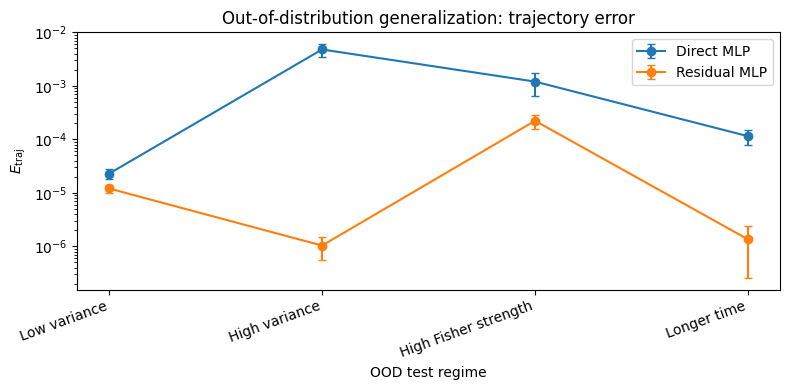

In [ ]:

plot_df = ood_summary.copy()

regime_order = ["Low variance", "High variance", "High Fisher strength", "Longer time"]
x = np.arange(len(regime_order))

plt.figure(figsize=(8, 4))

for model in ["Direct MLP", "Residual MLP"]:
    g = plot_df[plot_df["model"] == model].set_index("regime").loc[regime_order]
    y = g["E_traj_mean"].to_numpy()
    yerr = g["E_traj_ci"].to_numpy()
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=3, label=model)

plt.xticks(x, regime_order, rotation=20, ha="right")
plt.yscale("log")
plt.xlabel("OOD test regime")
plt.ylabel(r"$E_{\mathrm{traj}}$")
plt.title("Out-of-distribution generalization: trajectory error")
plt.legend()
plt.tight_layout()
plt.show()
